In [2]:
import numpy as np
import matplotlib.pyplot as plt 

In [ ]:
#Cas n°1 : Ici l'économie se déroule dans un environnement libre et stable, les agents sont rationnels, l'information est parfaite et il n'y a pas d'impact ni d'influence d'acteurs exterieurs (état etc..)
#il n'y a donc pas non plus de régulation ni d'intervention étatique et ni de bulles speculatives

In [74]:
def passage(matrice, etat):
    """ en fontion d'un état, cette fonction définit aléatoirement le prochain état du marché """
    nvetat = 0
    k = np.random.uniform()
    if k <matrice[etat][0]:
        nvetat =0
    else:
        if k < matrice[etat][0] + matrice[etat][1] and k >= matrice[etat][0]:   
            nvetat = 1
        else:
            nvetat = 2
    return nvetat

#on definit etat 0 = crise, etat 1 = stable, etat 2 = croissance


def probapopulation(etat, vecteurpopulation):
    """Fonction qui modifie l'opinion de la population en fonction de l'état du marché"""
    vecteur = []
    if etat == 0:
        return vecteurpopulation * 0.8
    if etat == 1:
        return vecteurpopulation
    if etat == 2: 
        for e in vecteurpopulation:
            if e*1.2<1:
               vecteur.append(e*1.2)
            else:
                vecteur.append(1)
        return np.array(vecteur)


def prop_investisseurs(etat):
    """fonction qui determine le nombre d'investisseurs en fonction de l'état du marché"""
    if etat == 2:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e > 0.4])
    if etat == 1:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e > 0.5])
    if etat == 0:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e > 0.6])
    
    return vecteur_investisseurs



def calculer_indice(vecteurindice, vecteur_investisseurs, etat, liste):
    """fonction qui calcule l'indice global du marché en fonction de l'état du marché et du nombre d'investisseurs"""
    res = 0
    print(vecteurindice)
    for i in range(len(vecteurindice)):
        res = 0
        if etat == 0:
            for inv in vecteur_investisseurs:
                res = res + np.random.normal(-0.02, 0.00001)          #on simplifie, tous les prix diminuent lors d'une crise
            #print(res)
            vecteurindice[i] += res

        if etat == 2:
            for inv in vecteur_investisseurs:
                res = res + np.random.normal(0.05, 0.00001)
            vecteurindice[i] += res

        if etat == 1:
            for inv in vecteur_investisseurs:
                res = res + np.random.normal(0, 0.00001)
            vecteurindice[i] += res
    nv_indice = np.mean(vecteurindice) 
    liste.append(nv_indice)
    return nv_indice



def probamatrice(matrice,etat, indice1, indice0, epsilon): 
    variation = (indice1 -indice0)/indice0
    sensibilité = epsilon

    if variation > 0:
        transfert = min(matrice[etat][0], abs(sensibilité*variation))
        matrice[etat][0] -= transfert 
        matrice[etat][2] += transfert
        matrice[etat][1] = 1 - matrice[etat][0] - matrice[etat][2]
    
    elif variation < 0:
        transfert = min(matrice[etat][2], abs(sensibilité*variation))
        matrice[etat][0] += transfert
        matrice[etat][2] -= transfert
        matrice[etat][1] = 1 - matrice[etat][0] - matrice[etat][2]     
    
    return matrice


In [76]:

def fonction_cas1(matrice, etat, vecteurpopulation, vecteurindice):
    nvetat = 0
    vecteur_indices = [1]
    matrice_pop = []
    vecteur_etats = [etat]
    
    for i in range(5):
        nvetat = passage(matrice, etat)

        vecteurpopulation = probapopulation(nvetat, vecteurpopulation)
        matrice_pop.append(vecteurpopulation.copy())

        vecteur_investisseurs = prop_investisseurs(nvetat)

        nouvel_indice = calculer_indice(vecteurindice, vecteur_investisseurs, nvetat, vecteur_indices)

        matrice = probamatrice(matrice, nvetat, vecteur_indices[i], vecteur_indices[i+1], 0.1)

        vecteur_etats.append(nvetat)
        etat = nvetat
    return matrice, vecteur_etats, vecteur_investisseurs, vecteur_indices, matrice_pop

    

In [82]:
#variables exogènes

indice0 = 1
population = 1000
titres = 25
res = [indice0]
matrice = [[0.7, 0.2, 0.1], [0.3, 0.4, 0.3], [0.1, 0.2, 0.7]]  #on a choisi que 3 états, on peut en choisir plus. 
etat = 1

vecteurpopulation = np.random.normal(0.5, 0.15, population) 
# vecteur contenant toutes les opinions de la population, aux extremes on a des gens qui investissent beaucoup ou peu les valeurs sont comprises entre 0 et 1

vecteurindices = np.array([np.random.uniform()*10 for _ in range(titres)])
#vecteur contenant tous les indices de prix  l'indice positif veut dire que les prix ont globalement augmenté, l'indice négatif veut dire que les prix ont globalement diminué
#les prix sont tirés aléatoirement entre 0 et 10 le choix de l'encadrement est arbitraire, on peut le changer

In [85]:
k = fonction_cas1(matrice, 0, vecteurpopulation, vecteurindices)

[155.25401643 153.697011   153.10820808 153.15269081 159.69003199
 155.10494999 160.38496234 158.43339597 150.62552023 152.77982587
 158.75444538 154.06916756 155.32921672 156.16192349 156.68210625
 159.60576977 158.354386   152.54551794 158.68512843 156.79056599
 150.62269177 154.81886666 154.16235729 152.13200539 158.13787077]
[155.2544693  153.69712522 153.10848416 153.15273487 159.69014387
 155.10482689 160.3846933  158.43393288 150.62554548 152.77982027
 158.75415433 154.06924938 155.32900795 156.16185863 156.68212589
 159.60579121 158.35427845 152.54522507 158.6854781  156.79041268
 150.62252375 154.81918332 154.16230901 152.13215964 158.13762043]
[155.25437867 153.69739186 153.10873024 153.15304602 159.69011455
 155.10480916 160.38469893 158.43381477 150.6255043  152.77954362
 158.75446989 154.06942307 155.32932703 156.16192833 156.68201016
 159.6060104  158.35396273 152.54533804 158.68520761 156.790365
 150.62228172 154.81939639 154.1618913  152.13213201 158.13805589]
[192.8543

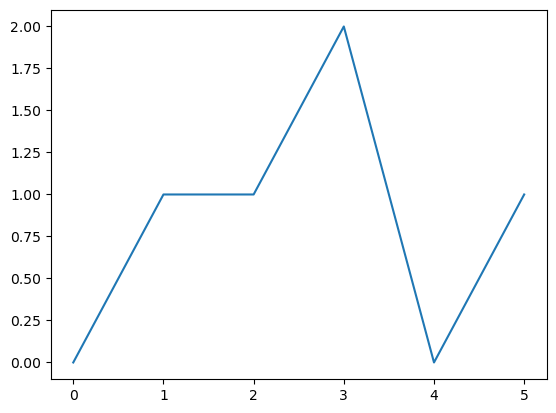

In [86]:
abscisse = np.arange(0, len(k[1]), 1)
plt.plot(abscisse, k[1])